In [3]:
import pandas as pd
import numpy as np

# Step 1: Import CSV
df = pd.read_csv("/content/social_media_engagement_5000.csv")

# Step 2: Inspect data
print(df.info())
print(df.head())

# Step 3: Handle missing values before converting
df['likes'] = df['likes'].fillna(0).astype(int)
df['comments'] = df['comments'].fillna(0).astype(int)
df['shares'] = df['shares'].fillna(0).astype(int)

# Step 4: Convert date column
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce', dayfirst=True)

# Step 5: NumPy operations
likes_array = df['likes'].to_numpy()
comments_array = df['comments'].to_numpy()

print("Average likes:", np.mean(likes_array))
print("Total comments:", np.sum(comments_array))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [4]:
# Check total missing values per column
print(df.isnull().sum())

# Alternative: df.isna().sum() does the same


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [5]:
# Drop rows where any of these columns are missing
df_clean_drop = df.dropna(subset=['age', 'gender', 'sentiment'])


In [6]:
# Median for numeric column
df['age'] = df['age'].fillna(df['age'].median())

# Mode for categorical columns
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])


In [7]:
# Already done
print(df.isnull().sum())


user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [9]:
# Forward fill
df_ffill = df.ffill()

# Backward fill
df_bfill = df.bfill()


In [11]:
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [12]:
# Find duplicate rows
duplicates = df[df.duplicated()]
print("Number of duplicate rows:", duplicates.shape[0])


Number of duplicate rows: 0


In [13]:
# Remove duplicate rows
df_no_duplicates = df.drop_duplicates()

# Verify again
print("Rows after removing duplicates:", df_no_duplicates.shape[0])


Rows after removing duplicates: 5000


In [14]:
# Check duplicates based on post_id
duplicates_post = df[df.duplicated(subset=['post_id'])]
print("Duplicate posts:", duplicates_post.shape[0])

# Remove duplicates based on post_id
df_unique_posts = df.drop_duplicates(subset=['post_id'])


Duplicate posts: 9


In [15]:
# Convert numeric columns to integers safely
df['likes'] = df['likes'].fillna(0).astype(int)
df['comments'] = df['comments'].fillna(0).astype(int)
df['shares'] = df['shares'].fillna(0).astype(int)

# Convert posted_at to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce', dayfirst=True)


In [16]:
# Normalize gender values
df['gender'] = df['gender'].str.strip().str.lower()

# Replace variations with standard labels
df['gender'] = df['gender'].replace({
    'male': 'Male',
    'female': 'Female',
    'other': 'Other',
    'm': 'Male',
    'f': 'Female'
})


In [17]:
# Example: remove rows with negative values
df = df[(df['likes'] >= 0) & (df['comments'] >= 0) & (df['shares'] >= 0)]

# Example: cap extreme outliers (optional)
df['likes'] = np.where(df['likes'] > 1e6, 1e6, df['likes'])
df['comments'] = np.where(df['comments'] > 1e5, 1e5, df['comments'])
df['shares'] = np.where(df['shares'] > 1e5, 1e5, df['shares'])


In [18]:
# Count number of hashtags per post
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))


In [19]:
# Normalize sentiment values
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Standardize to Positive / Negative / Neutral
df['sentiment'] = df['sentiment'].replace({
    'pos': 'positive',
    'neg': 'negative',
    'neu': 'neutral',
    'positive': 'positive',
    'negative': 'negative',
    'neutral': 'neutral'
})


In [20]:
print(df.dtypes)


user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object


In [21]:
print(df['gender'].unique())
print(df['sentiment'].unique())


['Female' 'Male' 'Other']
['negative' 'positive' 'neutral']


In [22]:
print(df[['likes','comments','shares']].describe())


              likes     comments       shares
count   5000.000000  5000.000000  5000.000000
mean    9803.832400  1457.129800   972.550600
std     5957.295788   893.917601   595.929688
min        0.000000     0.000000     0.000000
25%     4625.750000   675.000000   447.750000
50%     9776.000000  1454.500000   981.500000
75%    14959.000000  2235.250000  1483.000000
max    19998.000000  2999.000000  1999.000000


In [23]:
print(df[['hashtags','hashtag_count']].head())


                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [24]:
print(df['sentiment'].value_counts())


sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [25]:
# View first and last rows
print(df.head())      # First 5 rows
print(df.tail())      # Last 5 rows

# Shape and columns
print("Shape:", df.shape)       # (rows, columns)
print("Columns:", df.columns)   # Column names



   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile 

In [26]:
print(df.info())      # Detailed info
print(df.dtypes)      # Data types only


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [27]:
print(df.describe())  # Numeric summary
print(df.describe(include='object'))  # Categorical summary


            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000   9803.832400  1457.129800   
min    10055.000000    13.000000  100068.000000      0.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   4625.750000   675.000000   
50%    54374.500000    38.000000  548077.500000   9776.000000  1454.500000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5957.295788   893.917601   

            shares  watch_time_sec  impression_count  \
count  5000.000000     5000.000000       5000.000000   
mean    972.550600     4014.503200      50013.732800   
min       0.000000        0.000000        105.000000   
25%     447.750000     2017.750000      24988.250000   
50%     981.50000

In [28]:
# Value counts
print(df['gender'].value_counts())
print(df['post_type'].value_counts())

# Unique values
print(df['country'].unique())

# Number of unique values
print(df['hashtags'].nunique())


gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
761


In [29]:
# Correlation between numeric fields
print(df.corr(numeric_only=True))


                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.021377 -0.037686  0.015422   
age              -0.006688  1.000000 -0.013153 -0.039456 -0.006886  0.012572   
post_id           0.020051 -0.013153  1.000000  0.010650 -0.009489  0.004496   
likes             0.021377 -0.039456  0.010650  1.000000 -0.017593  0.001008   
comments         -0.037686 -0.006886 -0.009489 -0.017593  1.000000  0.006953   
shares            0.015422  0.012572  0.004496  0.001008  0.006953  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.002865 -0.017009  0.015372   
impression_count  0.015326  0.013322 -0.007709  0.002746 -0.009809  0.006399   
follower_count    0.010124 -0.024894 -0.002844 -0.023670 -0.008651 -0.005979   
is_verified       0.004058 -0.000079  0.025208 -0.011498 -0.010188  0.013042   
engagement_rate  -0.004282  0.008039  0.010139  0.094458  0.001464  0.021305   
hashtag_count    -0.013692  0.007173  0.

In [30]:
# Average likes by post type
print(df.groupby('post_type')['likes'].mean())

# Total impressions by country
print(df.groupby('country')['impression_count'].sum())

# Average engagement rate by sentiment
print(df.groupby('sentiment')['engagement_rate'].mean())


post_type
image    9845.542101
reel     9683.361652
text     9783.590361
video    9908.120816
Name: likes, dtype: float64
country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64
sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64


In [32]:
import numpy as np

# Create new fields
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df['log_likes'] = np.log1p(df['likes'])
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))

# GroupBy summaries
print(df.groupby('post_type')['engagement_score'].mean())
print(df.groupby('country')['impression_count'].sum())
print(df.groupby('sentiment')['engagement_rate'].mean())


post_type
image    12315.233360
reel     12089.823071
text     12221.308434
video    12313.221224
Name: engagement_score, dtype: float64
country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64
sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64


In [33]:
print("Mean likes:", df['likes'].mean())
print("Median likes:", df['likes'].median())
print("Mode likes:", df['likes'].mode()[0])

print("Mean comments:", df['comments'].mean())
print("Median comments:", df['comments'].median())
print("Mode comments:", df['comments'].mode()[0])


Mean likes: 9803.8324
Median likes: 9776.0
Mode likes: 0.0
Mean comments: 1457.1298
Median comments: 1454.5
Mode comments: 0.0


In [34]:
print("Std likes:", df['likes'].std())
print("Variance likes:", df['likes'].var())

print("Std comments:", df['comments'].std())
print("Variance comments:", df['comments'].var())


Std likes: 5957.2957882022265
Variance likes: 35489373.10813199
Std comments: 893.9176010614476
Variance comments: 799088.6774874534


In [35]:
print("25th percentile likes:", df['likes'].quantile(0.25))
print("50th percentile likes:", df['likes'].quantile(0.50))  # median
print("75th percentile likes:", df['likes'].quantile(0.75))


25th percentile likes: 4625.75
50th percentile likes: 9776.0
75th percentile likes: 14959.0


In [36]:
print("Skewness likes:", df['likes'].skew())
print("Kurtosis likes:", df['likes'].kurt())


Skewness likes: 0.00022752437537581355
Kurtosis likes: -1.2138961683852727


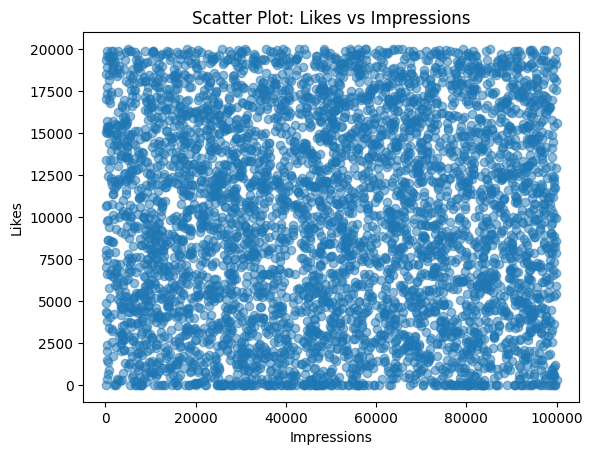

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df['impression_count'], df['likes'], alpha=0.5)
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Scatter Plot: Likes vs Impressions")
plt.show()


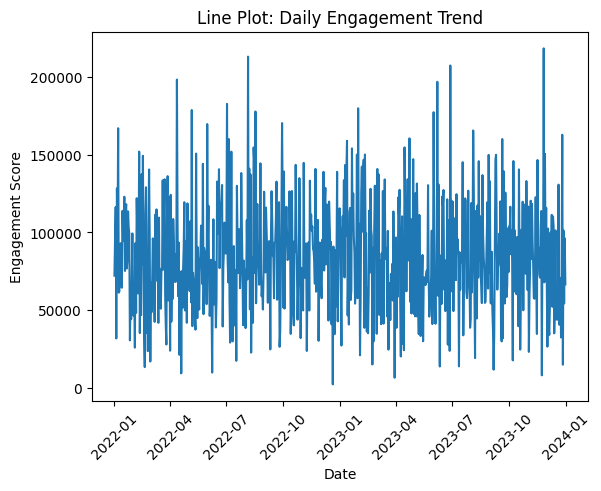

In [38]:
# Aggregate engagement_score by date
daily_engagement = df.groupby('posted_at')['engagement_score'].sum()

plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel("Date")
plt.ylabel("Engagement Score")
plt.title("Line Plot: Daily Engagement Trend")
plt.xticks(rotation=45)
plt.show()


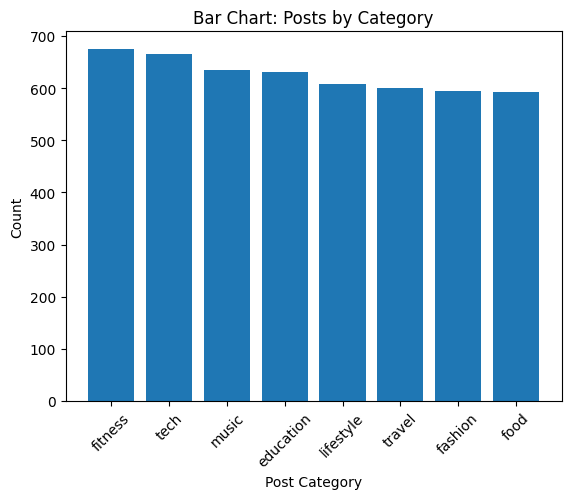

In [39]:
post_counts = df['post_category'].value_counts()

plt.bar(post_counts.index, post_counts.values)
plt.xlabel("Post Category")
plt.ylabel("Count")
plt.title("Bar Chart: Posts by Category")
plt.xticks(rotation=45)
plt.show()


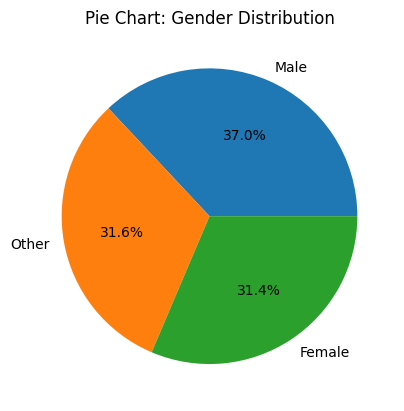

In [40]:
gender_counts = df['gender'].value_counts()

plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Pie Chart: Gender Distribution")
plt.show()


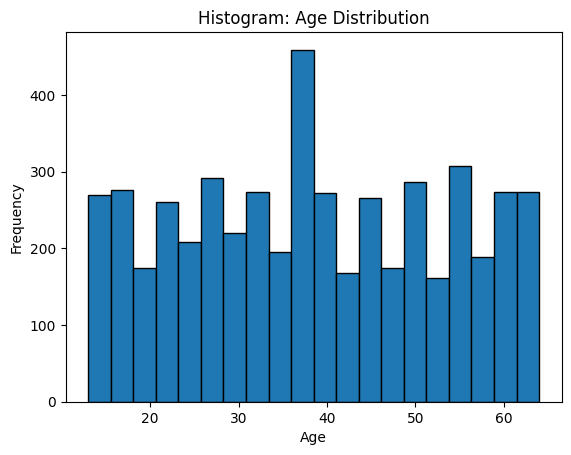

In [41]:
plt.hist(df['age'], bins=20, edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram: Age Distribution")
plt.show()


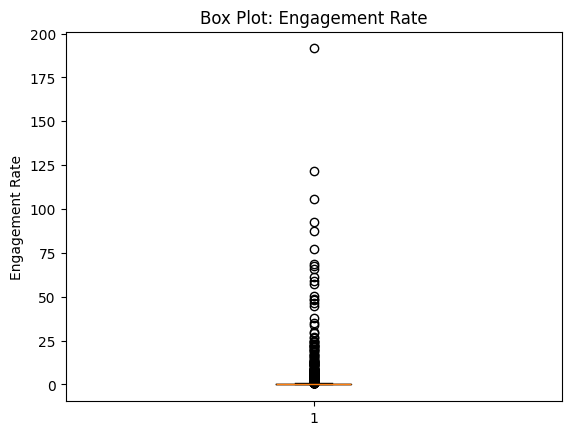

In [42]:
plt.boxplot(df['engagement_rate'])
plt.ylabel("Engagement Rate")
plt.title("Box Plot: Engagement Rate")
plt.show()


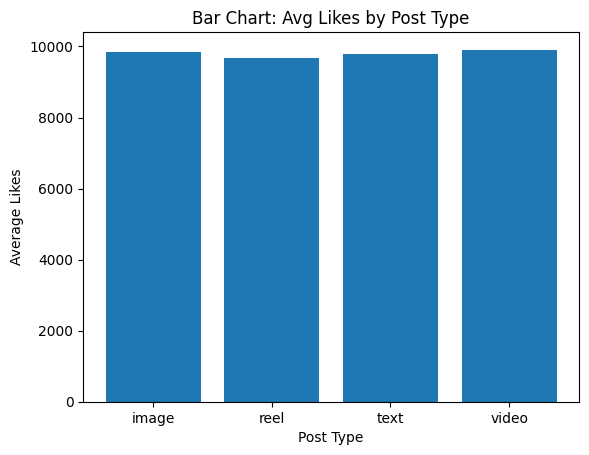

In [43]:
avg_likes = df.groupby('post_type')['likes'].mean()

plt.bar(avg_likes.index, avg_likes.values)
plt.xlabel("Post Type")
plt.ylabel("Average Likes")
plt.title("Bar Chart: Avg Likes by Post Type")
plt.show()


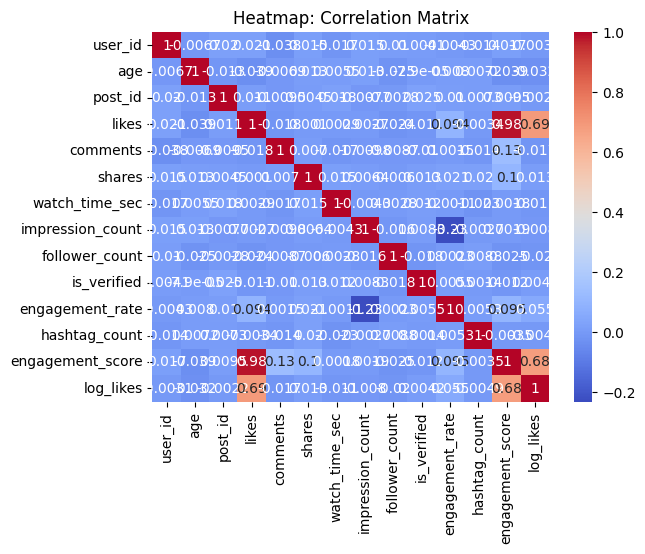

In [44]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap: Correlation Matrix")
plt.show()


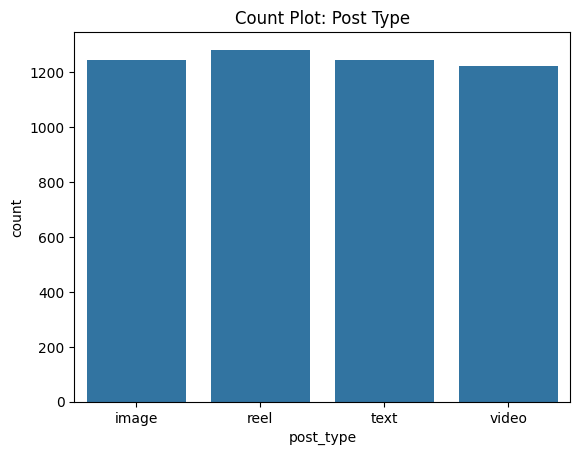

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='post_type', data=df)
plt.title("Count Plot: Post Type")
plt.show()


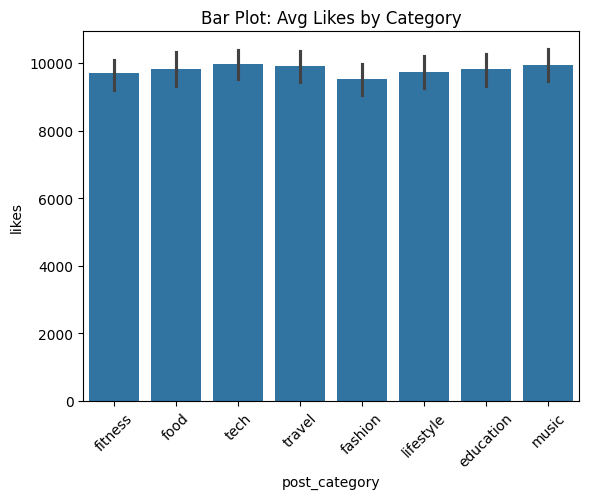

In [46]:
sns.barplot(x='post_category', y='likes', data=df, estimator=np.mean)
plt.title("Bar Plot: Avg Likes by Category")
plt.xticks(rotation=45)
plt.show()


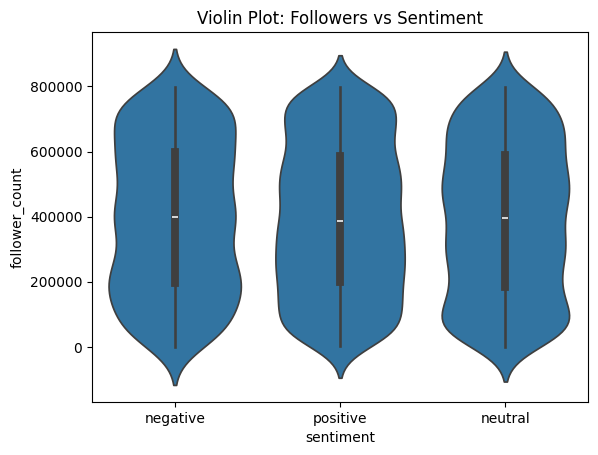

In [47]:
sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.title("Violin Plot: Followers vs Sentiment")
plt.show()


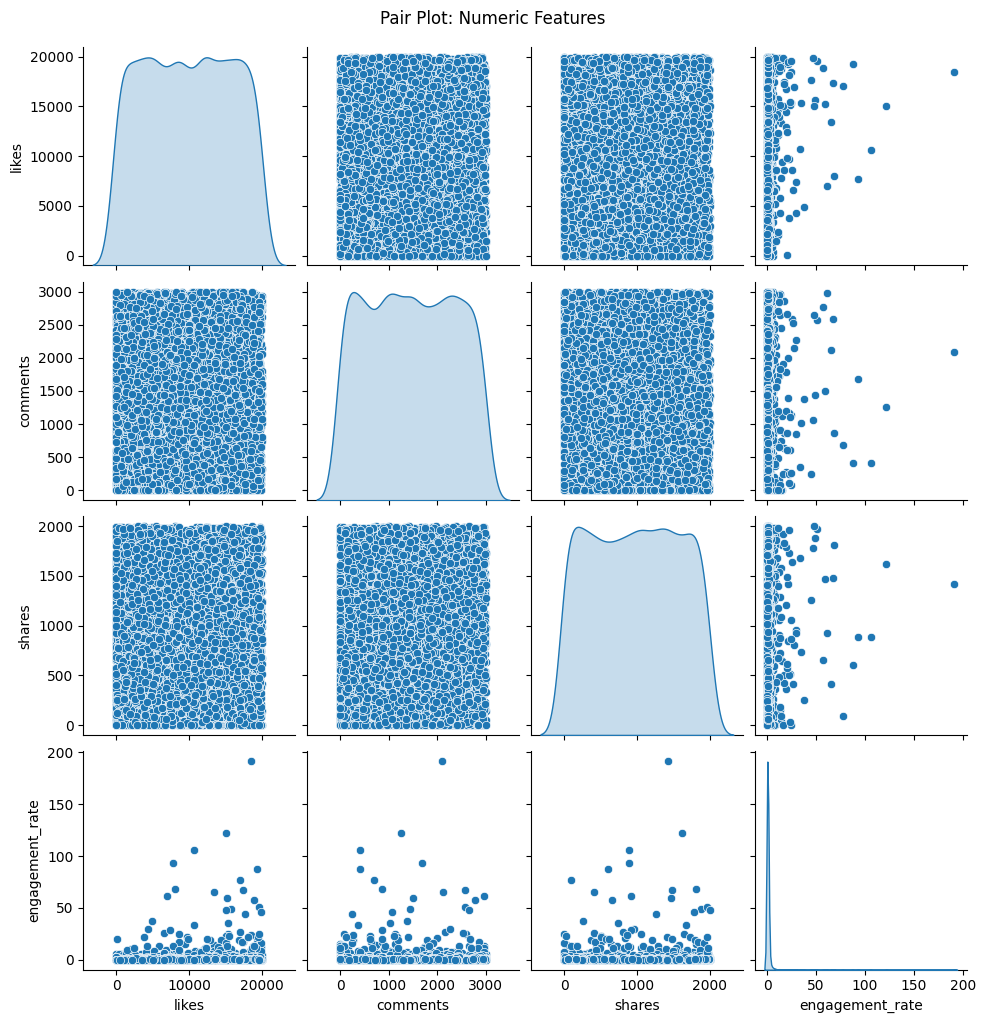

In [48]:
sns.pairplot(df[['likes','comments','shares','engagement_rate']], diag_kind='kde')
plt.suptitle("Pair Plot: Numeric Features", y=1.02)
plt.show()


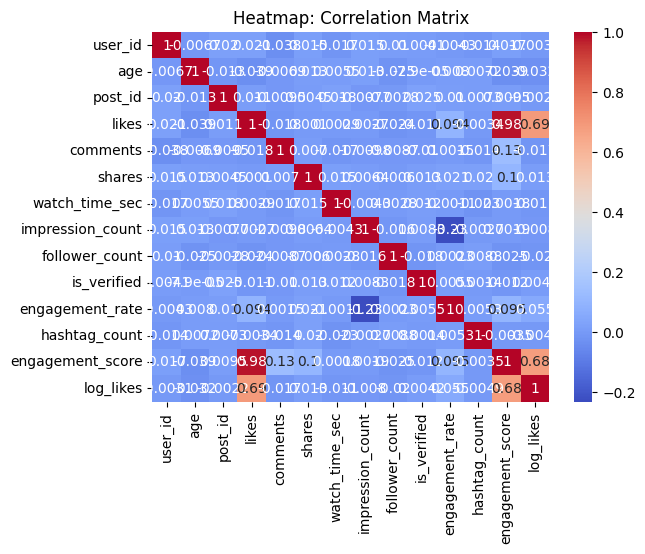

In [49]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap: Correlation Matrix")
plt.show()


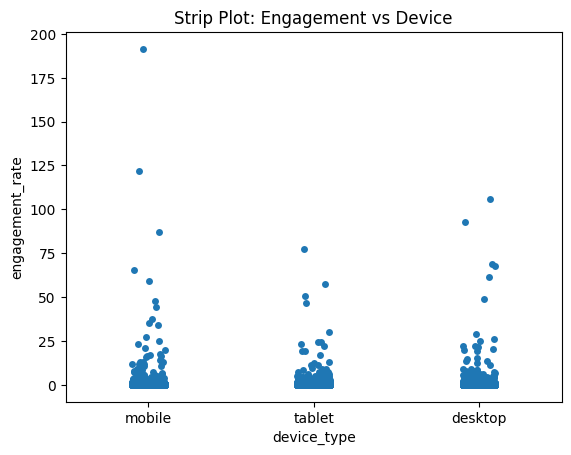

In [51]:
sns.stripplot(x='device_type', y='engagement_rate', data=df, jitter=True)
plt.title("Strip Plot: Engagement vs Device")
plt.show()


/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 80.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 81.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 82.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 84.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 85.3% of the points cannot be plac

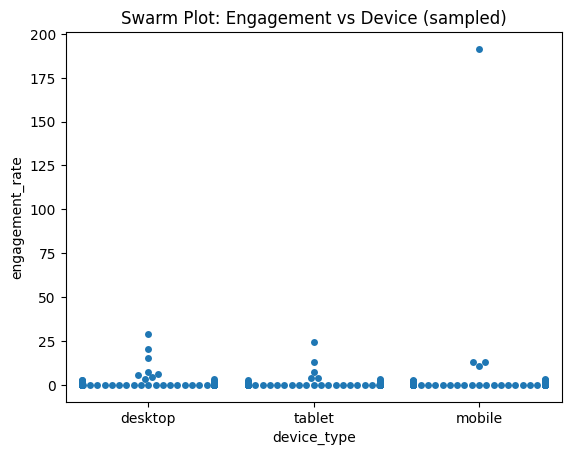

In [53]:
sns.swarmplot(x='device_type', y='engagement_rate', data=df.sample(500))
plt.title("Swarm Plot: Engagement vs Device (sampled)")
plt.show()


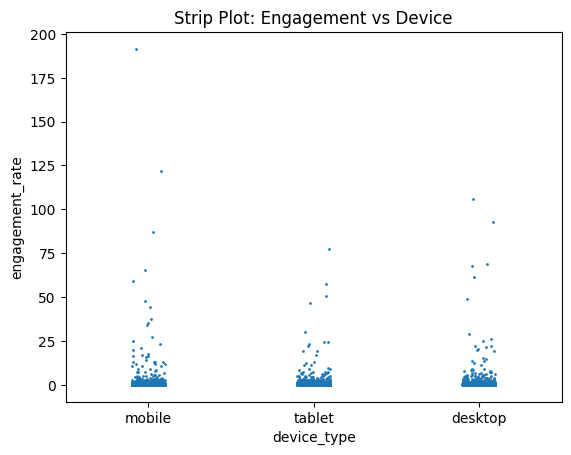

In [54]:
sns.stripplot(x='device_type', y='engagement_rate', data=df, jitter=True, size=2)
plt.title("Strip Plot: Engagement vs Device")
plt.show()


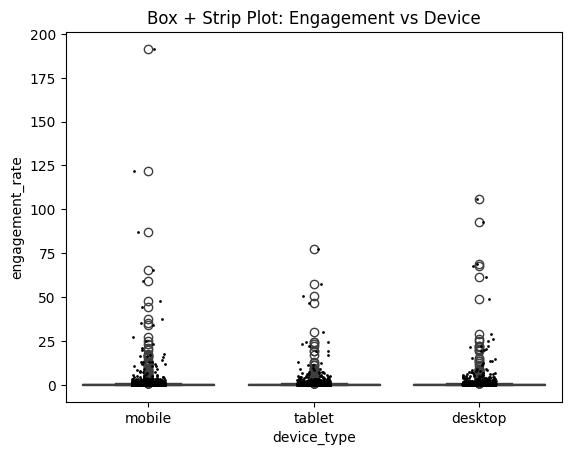

In [55]:
sns.boxplot(x='device_type', y='engagement_rate', data=df, whis=1.5)
sns.stripplot(x='device_type', y='engagement_rate', data=df, color='black', size=2, jitter=True)
plt.title("Box + Strip Plot: Engagement vs Device")
plt.show()


In [56]:
import plotly.express as px

daily_engagement = df.groupby('posted_at')['engagement_score'].sum().reset_index()

fig = px.line(daily_engagement, x='posted_at', y='engagement_score',
              title="Interactive Line Chart: Daily Engagement Trend")
fig.show()


In [58]:
import plotly.express as px

# Create a DataFrame of counts
post_counts = df['post_category'].value_counts().reset_index()
post_counts.columns = ['post_category', 'count']  # Rename columns clearly

# Plotly bar chart
fig = px.bar(post_counts,
             x='post_category', y='count',
             labels={'post_category':'Post Category','count':'Count'},
             title="Interactive Bar Chart: Posts by Category")
fig.show()


In [59]:
fig = px.scatter(df, x='follower_count', y='engagement_rate',
                 size='likes', color='sentiment',
                 hover_data=['post_type'],
                 title="Interactive Bubble Chart: Followers vs Engagement")
fig.show()


In [60]:
fig = px.scatter(df, x='impression_count', y='likes',
                 color='post_type', hover_data=['comments','shares'],
                 title="Interactive Scatter Chart: Likes vs Impressions")
fig.show()


In [61]:
df.groupby('post_type')['engagement_score'].mean().sort_values(ascending=False)


,engagement_score
post_type,
image,12315.233360
video,12313.221224
text,12221.308434
reel,12089.823071


In [62]:
df.groupby('post_category')['engagement_score'].mean().sort_values(ascending=False)


,engagement_score
post_category,
music,12442.215748
tech,12402.057143
travel,12267.180000
food,12258.352445
education,12196.129952
fitness,12187.059259
lifestyle,12120.566722
fashion,11970.826599


In [63]:
df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)


,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [64]:
df.groupby(pd.cut(df['age'], bins=[0,18,25,35,50,100]))['engagement_rate'].mean()


/tmp/ipykernel_1852/4063460189.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,engagement_rate
age,
"(0, 18]",0.867038
"(18, 25]",1.059536
"(25, 35]",0.865316
"(35, 50]",0.974237
"(50, 100]",1.020729


In [65]:
df.groupby('is_verified')['engagement_rate'].mean()


,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [66]:
df['hour'] = df['posted_at'].dt.hour
df.groupby('hour')['impression_count'].mean().sort_values(ascending=False)


,impression_count
hour,
0,50013.7328


In [67]:
df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)


,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


In [68]:
df.groupby('sentiment')['engagement_score'].mean().sort_values(ascending=False)


,engagement_score
sentiment,
negative,12352.977083
positive,12274.914047
neutral,12090.273084


In [69]:
df.groupby('sentiment')['comments'].mean()


,comments
sentiment,
negative,1478.669792
neutral,1488.209561
positive,1430.015917


In [70]:
df.groupby('sentiment')['engagement_rate'].mean()


,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744
